In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

liquidity_df = pd.read_excel("Liquidity Score/Liquidity_Pillar_Model_Outputs.xlsx")
inflation_df = pd.read_excel("Inflation Score/Output_Confirmed_Smooth_Inflation.xlsx")
rates_df = pd.read_excel("Rates Score/Rates_Regime_Final.xlsx")
growth_df = pd.read_excel("Growth Score/Growth_Pillar_Model_Outputs.xlsx")
external_stress_df = pd.read_excel("External Stress Score/Output_Confirmed_Smooth_External_Stress.xlsx")

df = pd.read_excel("Macro Pillars Attempt 2.xlsx")

df["Growth_Adjusted_Net_Score"] = growth_df["Adjusted_Net_Score"]
df["Inflation_Net_Composite_Score"] = inflation_df["Net_Composite_Score"]
df["Liquidity_Adjusted_Net_Score"] = liquidity_df["Adjusted_Net_Score"]
df["Rates_Final_Net_Score"] = rates_df["Final_Net_Score"]
df["External_Stress_Net_Score"] = external_stress_df["Net External Stress Score"]

df.to_excel("Macro Pillars Attempt 2.xlsx", index=False)


In [2]:
# =========================================================
# NO-PERSISTENCE VARIANT
# All hysteresis/persistence smoothing has been stripped from this version:
#   1. Step 3 (shock detection): shocks now fire on the raw single-month
#      threshold cross again -- SHOCK_CONFIRM_MONTHS is no longer applied.
#   2. Step 5 (regime confirmation): Base_Regime_Confirmed is now just an
#      alias for Base_Regime_Family -- no rolling-majority vote, no
#      confirmation window. CONFIRM_WINDOW / CONFIRM_VOTES below are UNUSED.
#   3. Step 6C (amplifier direction): reverted to the hard binary sign
#      split (Amplifier_Score >= 0 -> Headwind, else Tailwind) -- no more
#      forward-fill carry-forward across the neutral band.
# Everything else (pillar construction, momentum adjustment, amplifier
# weighting, regime strength bands) is unchanged from v3.
# =========================================================



# =========================================================
# CONFIG (v3) -- every hand-picked constant lives here, in one place,
# with a stated reason. Nothing in this block is fit to the data.
#
# Changed from v2, and why (full detail in the accompanying writeup):
#   1. Liquidity now has its OWN lag (0 months) instead of sharing the
#      3-month rates lag. Policy RATES transmit to the real economy slowly;
#      LIQUIDITY / credit-market stress transmits to markets almost
#      immediately, so lagging it by 3 months made the amplifier blind to
#      live liquidity crunches until they were already 3 months old.
#   2. Liquidity/credit stress now has its own shock detector, mirroring
#      the existing external-stress one. Previously a purely domestic
#      liquidity event (no matching spike in External Stress) could never
#      trigger Shock_Flag at all -- e.g. the 2022-23 RBI liquidity
#      tightening cycle, the most severe and sustained liquidity squeeze
#      in this sample, was never once flagged as a shock under v2.
#   3. The persistence/hysteresis vote now runs on regime FAMILY (a
#      Transitional print and the quadrant it's leaning toward are treated
#      as the same family) using a rolling majority vote, instead of "2
#      consecutive raw prints that merely disagree with the old confirmed
#      regime, even if they disagree with each other too." The old rule
#      let the confirmed regime snap to whatever the raw label happened to
#      be on month 2 without ever requiring the new regime to actually
#      repeat -- combined with month-to-month pillar noise that's
#      routinely bigger than the dead zone, this made the confirmed regime
#      flip on a median of ~2 months, too choppy to read as a "regime."
#      The persistence bypass on a shock also now fires only at shock
#      ONSET, not for every month a known, ongoing shock stays live.
#   4. REGIME_COMPOSITE_JUMP_THRESHOLD raised 0.40 -> 0.45: at 0.40 this
#      fired in ~9% of months, too routine to work as a rare "genuinely
#      fast-moving macro shift" override; 0.45 sits close to the empirical
#      95th percentile of the observed 1-month |composite| move.
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# CONFIG (v3) -- every hand-picked constant lives here
# =========================================================

# --- Data window ---
# Defines the start date for the historical dataset and the holdout period for backtesting
DATA_START = "2014-05-01"   
VALIDATION_HOLDOUT_START = "2023-01-01"

# --- Growth/Inflation composite weighting ---
# Core structural base of the macro environment
GROWTH_WEIGHT = 0.65
INFLATION_WEIGHT = 0.35
DEAD_ZONE = 0.20 # Threshold below which base momentum is considered neutral

# --- Momentum weight (growth/inflation) ---
# How much the rate-of-change influences the final base score
MOMENTUM_WEIGHT_NO_TREND = 0.40       
MOMENTUM_WEIGHT_DEFINED_TREND = 0.20  

# --- INDIVIDUAL PILLAR TRANSMISSION LAGS (Months) ---
# Adjust these to shift the underlying data forward, representing the delay 
# in transmission to the broader macro environment. These are applied upfront.
GROWTH_LAG_MONTHS = 0
INFLATION_LAG_MONTHS = 0
RATES_LAG_MONTHS = 0
LIQUIDITY_LAG_MONTHS = 0
STRESS_LAG_MONTHS = 0

# --- Amplifier weights, by which kind of shock (if any) is live ---
# Dynamically adjusts the importance of liquidity, rates, and stress depending on the environment
AMPLIFIER_WEIGHTS_NORMAL          = {"liquidity": 0.25, "rates": 0.50, "stress": 0.25}
AMPLIFIER_WEIGHTS_STRESS_SHOCK    = {"liquidity": 0.15, "rates": 0.25, "stress": 0.60}
AMPLIFIER_WEIGHTS_LIQUIDITY_SHOCK = {"liquidity": 0.60, "rates": 0.25, "stress": 0.15}
AMPLIFIER_WEIGHTS_RATES_SHOCK = {"liquidity": 0.20, "rates": 0.60, "stress": 0.20}
AMPLIFIER_WEIGHTS_COMPOUND_SHOCK  = {"liquidity": 0.33, "rates": 0.34, "stress": 0.33}

# --- Shock detection thresholds ---
# Triggers for shifting the amplifier weights above
STRESS_LEVEL_SHOCK_THRESHOLD = 0.60
STRESS_JUMP_SHOCK_THRESHOLD  = 0.40
LIQUIDITY_LEVEL_SHOCK_THRESHOLD = 0.60
LIQUIDITY_JUMP_SHOCK_THRESHOLD  = 0.40
RATES_LEVEL_SHOCK_THRESHOLD = 0.60   # mirrors Stress/Liquidity's level threshold
RATES_JUMP_SHOCK_THRESHOLD  = 0.40   # placeholder -- calibrate off the real 1m move distribution, same way 0.45 was picked as ~95th pctile for the composite jump

# --- Regime persistence / hysteresis ---
# UNUSED in this no-persistence variant (kept only so the original values
# are visible/recoverable if you want to reintroduce persistence later).
CONFIRM_WINDOW = 4       # unused
CONFIRM_VOTES = 2       # unused
REGIME_COMPOSITE_JUMP_THRESHOLD = 0.40  # still used -- drives the "[FAST MOVE]" display tag only, not a filter

# --- Regime strength bands ---
# Used to classify the intensity of the active regime
HEADWIND_STRENGTH_SIGNIFICANT = 0.5
HEADWIND_STRENGTH_MILD = 0.1
TAILWIND_STRENGTH_SIGNIFICANT = -0.5
TAILWIND_STRENGTH_MILD = -0.1


In [3]:
# =========================================================
# LOAD + CLEAN + APPLY LAGS
# =========================================================
# 1. Load the raw dataset
df = pd.read_excel("Macro Pillars Attempt 2.xlsx")
df.columns = df.columns.str.strip()

# 2. Standardize dates and sort chronologically
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df = df[df["Date"] >= DATA_START].reset_index(drop=True)

# 3. Define the core column names for the 5 pillars
growth_col     = "Growth_Adjusted_Net_Score"
inflation_col  = "Inflation_Net_Composite_Score"
liquidity_col  = "Liquidity_Adjusted_Net_Score"
rates_col      = "Rates_Final_Net_Score"
stress_col     = "External_Stress_Net_Score"

# 4. Clip outliers to ensure all scores remain within the [-1, 1] bounds
for c in [growth_col, inflation_col, liquidity_col, rates_col, stress_col]:
    df[c] = df[c].clip(-1, 1)

# 5. Apply individual pillar lags upfront
# By shifting the data forward here based on the Config variables, all downstream 
# momentum, shock, and regime calculations automatically inherit these transmission delays.
df[growth_col] = df[growth_col].shift(GROWTH_LAG_MONTHS)
df[inflation_col] = df[inflation_col].shift(INFLATION_LAG_MONTHS)
df[liquidity_col] = df[liquidity_col].shift(LIQUIDITY_LAG_MONTHS)
df[rates_col] = df[rates_col].shift(RATES_LAG_MONTHS)
df[stress_col] = df[stress_col].shift(STRESS_LAG_MONTHS)

# 6. Sanity check for validation window and data length
if (df["Date"] >= VALIDATION_HOLDOUT_START).any():
    print(f"NOTE: data includes the holdout window ({VALIDATION_HOLDOUT_START} onward).")

print(f"Loaded {len(df)} months, {df['Date'].min().date()} to {df['Date'].max().date()}")

NOTE: data includes the holdout window (2023-01-01 onward).
Loaded 145 months, 2014-05-31 to 2026-05-31


In [4]:
# =========================================================
# STEP 1 -- MOMENTUM ON GROWTH + INFLATION (unchanged from v2)
# =========================================================
def momentum_adjusted(level_series):
    mom_3m = (level_series - level_series.shift(3)) / 3
    weight = np.where(
        level_series.abs() < DEAD_ZONE,
        MOMENTUM_WEIGHT_NO_TREND,
        MOMENTUM_WEIGHT_DEFINED_TREND,
    )
    adjusted = level_series + weight * mom_3m.fillna(0)
    return adjusted.clip(-1, 1)

df["Growth_Final"]    = momentum_adjusted(df[growth_col])
df["Inflation_Final"] = momentum_adjusted(df[inflation_col])
df["Composite_Score"] = GROWTH_WEIGHT * df["Growth_Final"] + INFLATION_WEIGHT * df["Inflation_Final"]

print(df[["Date", growth_col, inflation_col, "Growth_Final", "Inflation_Final", "Composite_Score"]].tail(6).to_string(index=False))

      Date  Growth_Adjusted_Net_Score  Inflation_Net_Composite_Score  Growth_Final  Inflation_Final  Composite_Score
2025-12-31                   0.151136                         -1.000      0.172955        -1.000000        -0.237580
2026-01-31                   0.307955                         -0.500      0.333485        -0.466667         0.053432
2026-02-28                   0.128977                         -0.375      0.119508        -0.333333        -0.038987
2026-03-31                   0.062500                         -0.250      0.050682        -0.200000        -0.037057
2026-04-30                   0.175000                         -0.125      0.157273        -0.075000         0.075977
2026-05-31                  -0.073529                          0.125     -0.100530         0.191667         0.001739


In [5]:
# =========================================================
# STEP 2 -- RAW BASE REGIME + FAMILY
# The raw quadrant/label logic is unchanged from v2. What's new is
# Base_Regime_Family (v3), which collapses "Transitional (leaning X)" and
# "X" into the same family "X". This is what Step 5's persistence vote
# runs on, so a print that merely crosses the dead-zone boundary within
# the same lean no longer counts as disagreement with an already-confirmed
# regime -- only an actual change of lean does.
# =========================================================
def axis_sign(x):
    if x > DEAD_ZONE:
        return 1
    elif x < -DEAD_ZONE:
        return -1
    return 0

QUADRANT = {
    (-1, -1): "Goldilocks",
    (-1,  1): "Reflation",
    ( 1,  1): "Stagflation",
    ( 1, -1): "Deflation",
}

def base_regime_raw(row):
    g_raw, i_raw = row[growth_col], row[inflation_col]
    g_sign, i_sign = axis_sign(g_raw), axis_sign(i_raw)

    if g_sign != 0 and i_sign != 0:
        return QUADRANT[(g_sign, i_sign)]

    g_lean = g_sign if g_sign != 0 else (1 if row["Growth_Final"] > 0 else -1)
    i_lean = i_sign if i_sign != 0 else (1 if row["Inflation_Final"] > 0 else -1)

    return f"Transitional (leaning {QUADRANT[(g_lean, i_lean)]})"

def regime_family(label):
    if label.startswith("Transitional (leaning "):
        return label[len("Transitional (leaning "):-1]
    return label

df["Base_Regime_Raw"] = df.apply(base_regime_raw, axis=1)
df["Base_Regime_Family"] = df["Base_Regime_Raw"].apply(regime_family)

print("Raw label value counts:")
print(df["Base_Regime_Raw"].value_counts())
print()
print("Collapsed to family:")
print(df["Base_Regime_Family"].value_counts())

Raw label value counts:
Base_Regime_Raw
Transitional (leaning Goldilocks)     27
Transitional (leaning Deflation)      27
Transitional (leaning Reflation)      25
Deflation                             20
Reflation                             17
Transitional (leaning Stagflation)    14
Goldilocks                            12
Stagflation                            3
Name: count, dtype: int64

Collapsed to family:
Base_Regime_Family
Deflation      47
Reflation      42
Goldilocks     39
Stagflation    17
Name: count, dtype: int64


In [6]:
# =========================================================
# STEP 3 -- SHOCK DETECTION (NO-PERSISTENCE VARIANT)
# The 2-consecutive-month shock confirmation has been removed. A shock now
# fires the same month the raw threshold is crossed (level breach OR 1-month
# jump breach), full stop. SHOCK_CONFIRM_MONTHS / confirm_shock() from the
# persistence version are gone -- Stress_Shock / Liquidity_Shock / Rates_Shock
# are now just aliases for their _Raw single-month counterparts.
# =========================================================

stress_raw = df[stress_col]
stress_jump_1m = stress_raw - stress_raw.shift(1)
df["Stress_Shock_Raw"] = (stress_raw > STRESS_LEVEL_SHOCK_THRESHOLD) | (stress_jump_1m > STRESS_JUMP_SHOCK_THRESHOLD)
df["Stress_Shock"] = df["Stress_Shock_Raw"]

liquidity_raw = df[liquidity_col]
liquidity_jump_1m = liquidity_raw - liquidity_raw.shift(1)
df["Liquidity_Shock_Raw"] = (liquidity_raw > LIQUIDITY_LEVEL_SHOCK_THRESHOLD) | (liquidity_jump_1m > LIQUIDITY_JUMP_SHOCK_THRESHOLD)
df["Liquidity_Shock"] = df["Liquidity_Shock_Raw"]

rates_raw = df[rates_col]
rates_jump_1m = rates_raw - rates_raw.shift(1)
df["Rates_Shock_Raw"] = (rates_raw > RATES_LEVEL_SHOCK_THRESHOLD) | (rates_jump_1m > RATES_JUMP_SHOCK_THRESHOLD)
df["Rates_Shock"] = df["Rates_Shock_Raw"]

df["Shock_Flag"] = df["Stress_Shock"] | df["Liquidity_Shock"] | df["Rates_Shock"]

composite_jump_1m = df["Composite_Score"] - df["Composite_Score"].shift(1)
df["Regime_Composite_Shock"] = composite_jump_1m.abs() > REGIME_COMPOSITE_JUMP_THRESHOLD

# Override_Persistence / Shock_Onset are kept only because Step 6's output
# columns and Step 7's diagnostics still reference them -- they no longer
# drive any decision now that Step 5 has no persistence to override.
df["Shock_Onset"] = df["Shock_Flag"] & ~df["Shock_Flag"].shift(1, fill_value=False)
df["Override_Persistence"] = df["Shock_Onset"] | df["Regime_Composite_Shock"]

print(f"Stress_Shock (raw, single-month):    {df['Stress_Shock'].sum():3d} / {len(df)}")
print(f"Liquidity_Shock (raw, single-month): {df['Liquidity_Shock'].sum():3d} / {len(df)}")
print(f"Rates_Shock (raw, single-month):     {df['Rates_Shock'].sum():3d} / {len(df)}")
print(f"Combined Shock_Flag:                 {df['Shock_Flag'].sum():3d} / {len(df)}  (drives amplifier weighting)")
print(f"Regime_Composite_Shock:              {df['Regime_Composite_Shock'].sum():3d} / {len(df)}")


Stress_Shock (raw, single-month):     10 / 145
Liquidity_Shock (raw, single-month):   5 / 145
Rates_Shock (raw, single-month):      20 / 145
Combined Shock_Flag:                  32 / 145  (drives amplifier weighting)
Regime_Composite_Shock:                7 / 145


In [7]:
# =========================================================
# STEP 4 -- AMPLIFIERS: Liquidity + Rates + External Stress
# =========================================================
# Note: Transmission lags for these pillars are now handled entirely upstream in Cell 2.
# This step calculates the dynamic Amplifier Score based on the presence of active shocks.

# Smooth out the external stress pillar slightly to prevent head-fakes
df["Stress_Smoothed"] = df[stress_col].rolling(2, min_periods=1).mean()

# Define a helper function to route the correct weighting dictionary based on shock status
def amplifier_weights(row):
    shocks_live = sum([row["Stress_Shock"], row["Liquidity_Shock"], row["Rates_Shock"]])
    if shocks_live > 2:
        return AMPLIFIER_WEIGHTS_COMPOUND_SHOCK
    if row["Liquidity_Shock"]:
        return AMPLIFIER_WEIGHTS_LIQUIDITY_SHOCK
    if row["Stress_Shock"]:
        return AMPLIFIER_WEIGHTS_STRESS_SHOCK
    if row["Rates_Shock"]:
        return AMPLIFIER_WEIGHTS_RATES_SHOCK
    return AMPLIFIER_WEIGHTS_NORMAL

# Calculate the final blended Amplifier Score for each row
def amplifier_score(row):
    weights = amplifier_weights(row)
    liq, rate, stress = row[liquidity_col], row[rates_col], row["Stress_Smoothed"]
    
    # Return NaN if any of the underlying amplifier data is missing due to upstream lags
    if pd.isna(liq) or pd.isna(rate) or pd.isna(stress):
        return np.nan
        
    return weights["liquidity"] * liq + weights["rates"] * rate + weights["stress"] * stress

# Apply the calculation and constrain the final output to [-1, 1]
df["Amplifier_Score"] = df.apply(amplifier_score, axis=1).clip(-1, 1)

print(df[["Date", liquidity_col, rates_col, "Stress_Smoothed", "Amplifier_Score"]].tail(6).to_string(index=False))

      Date  Liquidity_Adjusted_Net_Score  Rates_Final_Net_Score  Stress_Smoothed  Amplifier_Score
2025-12-31                 -2.775558e-17              -0.333333         0.000000        -0.166667
2026-01-31                  2.500000e-02              -0.500000         0.053125        -0.230469
2026-02-28                 -3.750000e-01              -0.666667         0.000000        -0.427083
2026-03-31                 -2.250000e-01              -0.500000         0.134375        -0.272656
2026-04-30                 -1.875000e-01              -0.333333         0.375000        -0.119792
2026-05-31                  2.312500e-01               0.000000         0.468750         0.209063


In [8]:
# =========================================================
# STEP 5 -- PERSISTENCE / HYSTERESIS -- REMOVED
# Base_Regime_Confirmed is now a direct alias for Base_Regime_Family (Step 2).
# No rolling-majority vote, no CONFIRM_WINDOW / CONFIRM_VOTES, no persistence
# bypass logic. This is the raw, unsmoothed monthly classification.
# =========================================================
df["Base_Regime_Confirmed"] = df["Base_Regime_Family"]

print(df[["Date", "Base_Regime_Family", "Base_Regime_Confirmed"]].tail(10).to_string(index=False))


      Date Base_Regime_Family Base_Regime_Confirmed
2025-08-31          Deflation             Deflation
2025-09-30         Goldilocks            Goldilocks
2025-10-31         Goldilocks            Goldilocks
2025-11-30          Deflation             Deflation
2025-12-31          Deflation             Deflation
2026-01-31          Deflation             Deflation
2026-02-28          Deflation             Deflation
2026-03-31          Deflation             Deflation
2026-04-30          Deflation             Deflation
2026-05-31          Reflation             Reflation


In [9]:
# =========================================================
# STEP 6 -- REGIME STRENGTH + FINAL LABEL
# The shock tag now distinguishes stress vs liquidity vs both, instead of a
# single generic [SHOCK], since a Ukraine-war-style external stress shock
# and a 2018/2022-23-style domestic liquidity squeeze are different animals.
# =========================================================
def classify_strength(score):
    if pd.isna(score):
        return "Insufficient Data"
    if score > HEADWIND_STRENGTH_SIGNIFICANT:
        return "Significant Headwind"
    elif score > HEADWIND_STRENGTH_MILD:
        return "Headwind"
    elif score < TAILWIND_STRENGTH_SIGNIFICANT:
        return "Significant Tailwind"
    elif score < TAILWIND_STRENGTH_MILD:
        return "Tailwind"
    return "Neutral"

df["Regime_Strength"] = df["Amplifier_Score"].apply(classify_strength)
df["Final_Regime"] = df["Base_Regime_Confirmed"] + " - " + df["Regime_Strength"]

def shock_tag(row):
    if row["Stress_Shock"] and row["Liquidity_Shock"]:
        return " [STRESS+LIQUIDITY SHOCK]"
    if row["Stress_Shock"]:
        return " [STRESS SHOCK]"
    if row["Liquidity_Shock"]:
        return " [LIQUIDITY SHOCK]"
    return ""

df["Final_Regime"] = df["Final_Regime"] + df.apply(shock_tag, axis=1)
df.loc[df["Regime_Composite_Shock"] & ~df["Shock_Flag"], "Final_Regime"] = df["Final_Regime"] + " [FAST MOVE]"

# =========================================================
# STEP 6B -- MACRO NARRATIVE MAPPING
# Interpreting the convergence or divergence of the real economy
# (Base Regime) and financial/policy conditions (Regime Strength).
# =========================================================

def determine_macro_narrative(row):
    base = row["Base_Regime_Confirmed"]
    strength = row["Regime_Strength"]
    
    # Group the strengths for easier logic mapping
    is_tailwind = "Tailwind" in strength
    is_headwind = "Headwind" in strength
    is_neutral = strength == "Neutral"
    
    if is_neutral:
        return "Organic " + base + " (No Major Policy/Financial Distortion)"
        
    # --- STAGFLATION NARRATIVES ---
    if base == "Stagflation":
        if is_tailwind:
            return "Counter-Cyclical Easing (Stimulus/Rescue against Stagflation)"
        elif is_headwind:
            return "Pro-Cyclical Tightening (Demand Destruction / Inflation Fight)"
            
    # --- DEFLATION NARRATIVES ---
    elif base == "Deflation":
        if is_tailwind:
            return "Counter-Cyclical Easing (Stimulus/Rescue against Deflation)"
        elif is_headwind:
            return "Pro-Cyclical Weakness (Liquidity Crunch / Deepening Crisis)"
            
    # --- REFLATION NARRATIVES ---
    elif base == "Reflation":
        if is_tailwind:
            return "Pro-Cyclical Boom (Supported Expansion / High Liquidity)"
        elif is_headwind:
            return "Counter-Cyclical Tightening (Soft Landing Attempt / Cooling off)"
            
    # --- GOLDILOCKS NARRATIVES ---
    elif base == "Goldilocks":
        if is_tailwind:
            return "Unchecked Boom (Overheating Risk / Asset Bubble Territory)"
        elif is_headwind:
            return "Late-Cycle Normalization (Taking away the policy punchbowl)"
            
    return "Unknown Interaction"

df["Macro_Narrative"] = df.apply(determine_macro_narrative, axis=1)

# Append shock tags to the narrative so you don't lose the live-crisis context
def narrative_with_shock(row):
    shock = shock_tag(row)
    if shock:
        return row["Macro_Narrative"] + shock
    return row["Macro_Narrative"]

df["Macro_Narrative"] = df.apply(narrative_with_shock, axis=1)

# ==============================================================================
# STEP 6C -- BACKTEST OCTANT (4 base regimes x 2 amplifier directions)
# NO-PERSISTENCE VARIANT: reverted to a hard binary sign split, no neutral
# band, no forward-fill carry-forward. Every month gets an instantaneous
# direction straight off the raw Amplifier_Score sign.
# ==============================================================================
df['Amplifier_Direction'] = np.where(df['Amplifier_Score'] >= 0, 'Headwind', 'Tailwind')

# Build the Backtest Octant label
df["Backtest_Octant"] = df["Base_Regime_Confirmed"] + " " + df["Amplifier_Direction"]

print("--- BACKTEST OCTANT SAMPLE SIZES (N) ---")
print(df["Backtest_Octant"].value_counts())

# ==============================================================================
# OUTPUT
# ==============================================================================
output_cols = [
    "Date", growth_col, inflation_col, "Growth_Final", "Inflation_Final", "Composite_Score",
    "Base_Regime_Raw", "Base_Regime_Family", "Base_Regime_Confirmed",
    liquidity_col, rates_col, stress_col,
    "Stress_Smoothed", # Note: "Liquidity_Lagged" and "Rates_Lagged" removed as lags are now applied upfront
    "Amplifier_Score", "Regime_Strength",
    "Stress_Shock", "Liquidity_Shock", "Shock_Flag", "Shock_Onset",
    "Regime_Composite_Shock", "Override_Persistence", "Final_Regime",
    "Macro_Narrative", "Amplifier_Direction", "Backtest_Octant" # <-- Added here
]

df_output = df[output_cols]
df_output.to_excel("V7_Regime_Output_NoPersistence.xlsx", index=False)
print("Saved.")

--- BACKTEST OCTANT SAMPLE SIZES (N) ---
Backtest_Octant
Deflation Tailwind      38
Reflation Headwind      22
Goldilocks Headwind     21
Reflation Tailwind      20
Goldilocks Tailwind     18
Stagflation Tailwind    13
Deflation Headwind       9
Stagflation Headwind     4
Name: count, dtype: int64
Saved.


In [10]:
# =========================================================
# BASE REGIME x AMPLIFIER COUPLING CHECK
# =========================================================
# Tests how deterministic each base regime's amplifier direction really is.
# If a base family is >90% one direction, the amplifier isn't adding much
# independent information for that family -- it's just confirming the
# base regime (expected, since the amplifier is a policy reaction function).
# Uses the same `df` already built in the plotting cell above.

# --- 1. Month-level coupling: % Tailwind vs Headwind within each base family ---
coupling_counts = pd.crosstab(df['Base_Regime_Confirmed'], df['Amplifier_Direction'])
coupling_pct = pd.crosstab(df['Base_Regime_Confirmed'], df['Amplifier_Direction'], normalize='index') * 100

family_order = ["Goldilocks", "Reflation", "Stagflation", "Deflation"]
coupling_counts = coupling_counts.reindex(family_order)
coupling_pct = coupling_pct.reindex(family_order)

print("--- MONTH COUNTS: Base Regime x Amplifier Direction ---")
print(coupling_counts)
print("\n--- % SPLIT WITHIN EACH BASE FAMILY ---")
print(coupling_pct.round(1))

# --- 2. Episode-level counts: contiguous runs, not raw months ---
# Hysteresis means regimes persist in runs, so month-counts overstate how
# many independent "episodes" actually back each octant. This collapses
# consecutive months of the same octant into a single episode.
octant_series = df['Backtest_Octant']
episode_id = (octant_series != octant_series.shift()).cumsum()
episodes = df.groupby(episode_id).agg(
    Octant=('Backtest_Octant', 'first'),
    Start=('Date', 'first'),
    End=('Date', 'last'),
    Months=('Date', 'count')
).reset_index(drop=True)

episode_counts = episodes.groupby('Octant').agg(
    N_Episodes=('Octant', 'count'),
    Total_Months=('Months', 'sum'),
    Avg_Episode_Length=('Months', 'mean')
)

octant_order = [f"{fam} + {direction}" for fam in family_order for direction in ["Tailwind", "Headwind"]]
episode_counts = episode_counts.reindex([o for o in octant_order if o in episode_counts.index])

print("\n--- EPISODE COUNTS BY OCTANT (contiguous runs, not raw months) ---")
print(episode_counts.round(1))

# --- 3. Flag which base families have a genuinely bimodal amplifier split ---
# vs. ones where the amplifier is structurally lopsided (organic/expected pairing).
print("\n--- COUPLING VERDICT ---")
for fam in family_order:
    if fam not in coupling_pct.index:
        continue
    row = coupling_pct.loc[fam].dropna()
    dominant_pct = row.max()
    if dominant_pct >= 85:
        verdict = "LOPSIDED -- amplifier mostly confirms base regime; treat rare direction as a flagged stress override, not a separately tested octant"
    elif dominant_pct >= 65:
        verdict = "SKEWED -- amplifier adds some information, but one direction dominates"
    else:
        verdict = "BIMODAL -- amplifier genuinely splits this family; keep both octants as separately testable"
    print(f"{fam:12s} | dominant direction {dominant_pct:5.1f}% | {verdict}")

--- MONTH COUNTS: Base Regime x Amplifier Direction ---
Amplifier_Direction    Headwind  Tailwind
Base_Regime_Confirmed                    
Goldilocks                   21        18
Reflation                    22        20
Stagflation                   4        13
Deflation                     9        38

--- % SPLIT WITHIN EACH BASE FAMILY ---
Amplifier_Direction    Headwind  Tailwind
Base_Regime_Confirmed                    
Goldilocks                 53.8      46.2
Reflation                  52.4      47.6
Stagflation                23.5      76.5
Deflation                  19.1      80.9

--- EPISODE COUNTS BY OCTANT (contiguous runs, not raw months) ---
Empty DataFrame
Columns: [N_Episodes, Total_Months, Avg_Episode_Length]
Index: []

--- COUPLING VERDICT ---
Goldilocks   | dominant direction  53.8% | BIMODAL -- amplifier genuinely splits this family; keep both octants as separately testable
Reflation    | dominant direction  52.4% | BIMODAL -- amplifier genuinely splits this fa

In [11]:
# =========================================================
# STEP 7 -- SANITY DIAGNOSTICS (new in v3)
# Quick self-check on regime stability. Re-run this after any config change
# or data refresh: a healthy macro regime series should have confirmed
# spells lasting multiple months, not flipping every month or two.
# (In this no-persistence variant, expect much shorter/choppier spells --
# that's the point of removing the smoothing, not a bug.)
# =========================================================
switch = df["Base_Regime_Confirmed"] != df["Base_Regime_Confirmed"].shift(1)
spell_id = switch.cumsum()
spell_lens = df.groupby(spell_id).size()

print(f"Months covered:              {len(df)}")
print(f"Total confirmed-regime switches: {switch.sum() - 1}")
print(f"Median spell length (months):    {spell_lens.median()}")
print(f"Mean spell length (months):      {spell_lens.mean():.2f}")
print(f"1-month spells:                  {(spell_lens == 1).sum()} / {len(spell_lens)}")
print()
# Override_Persistence no longer bypasses anything (Step 5 has no persistence
# left to override) -- printed only for reference against the original version.
print(f"Override_Persistence rate (vestigial, no persistence to bypass): {df['Override_Persistence'].sum()} / {len(df)} "
      f"({df['Override_Persistence'].mean()*100:.1f}%)")
print(f"Shock_Flag rate (amplifier weighting): {df['Shock_Flag'].sum()} / {len(df)} "
      f"({df['Shock_Flag'].mean()*100:.1f}%)")
print()
print("Final_Regime value counts (top 10):")
print(df["Final_Regime"].value_counts().head(10))


Months covered:              145
Total confirmed-regime switches: 49
Median spell length (months):    2.0
Mean spell length (months):      2.90
1-month spells:                  16 / 50

Override_Persistence rate (vestigial, no persistence to bypass): 21 / 145 (14.5%)
Shock_Flag rate (amplifier weighting): 32 / 145 (22.1%)

Final_Regime value counts (top 10):
Final_Regime
Deflation - Tailwind                25
Goldilocks - Tailwind               15
Reflation - Tailwind                15
Goldilocks - Neutral                 9
Stagflation - Tailwind               9
Reflation - Significant Headwind     9
Goldilocks - Headwind                9
Deflation - Neutral                  6
Reflation - Neutral                  5
Reflation - Headwind                 5
Name: count, dtype: int64


--- PEARSON CORRELATION (Lag=0m) ---
Composite_Score   -0.441039
Amplifier_Score    0.423798
CEIC_Smoothed      1.000000
Name: CEIC_Smoothed, dtype: float64

--- STATISTICAL AGGREGATION BY OCTANT ---
Empty DataFrame
Columns: [(CEIC_Smoothed, median), (CEIC_Smoothed, mean), (CEIC_Smoothed, count)]
Index: []


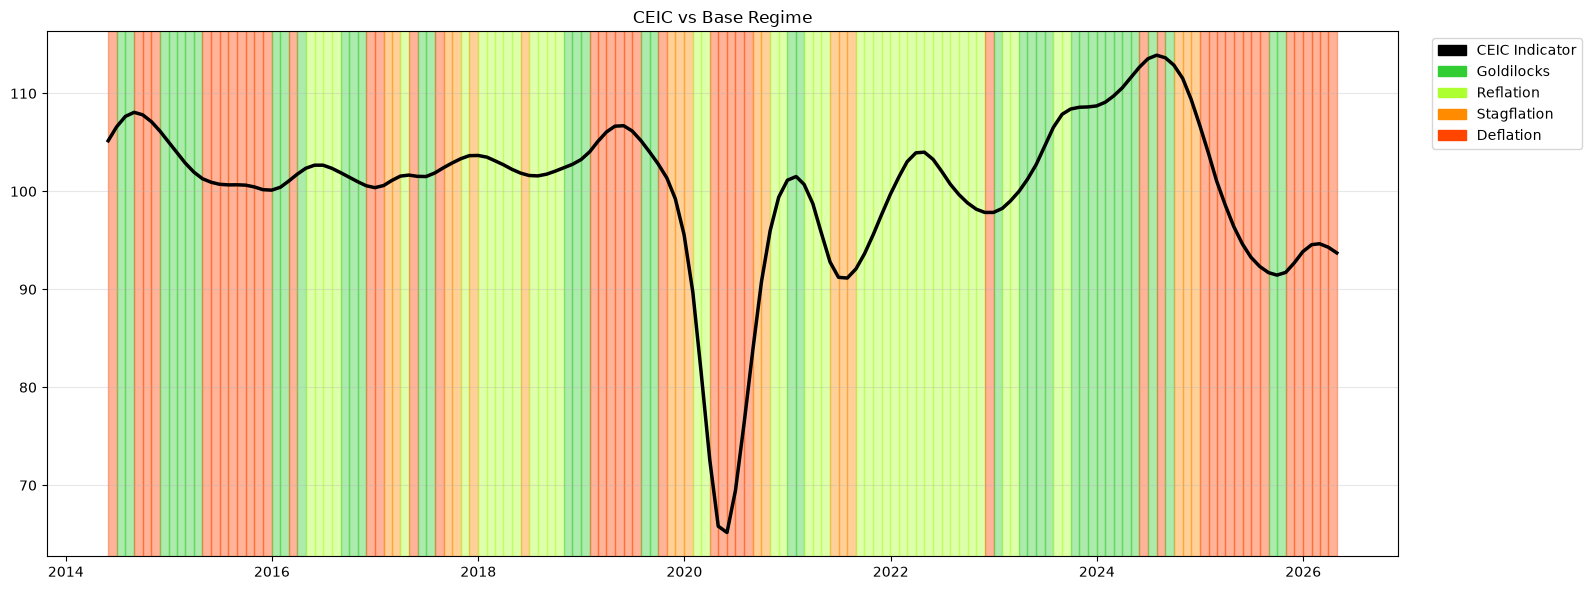

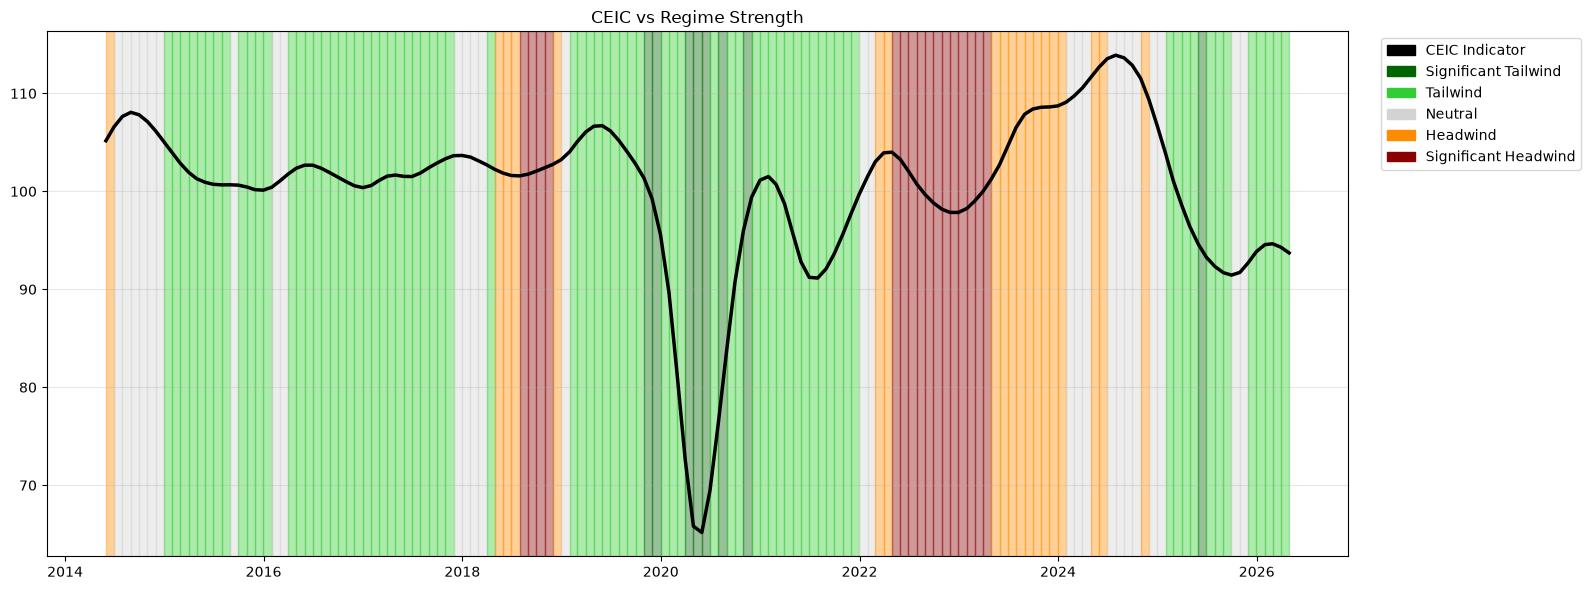

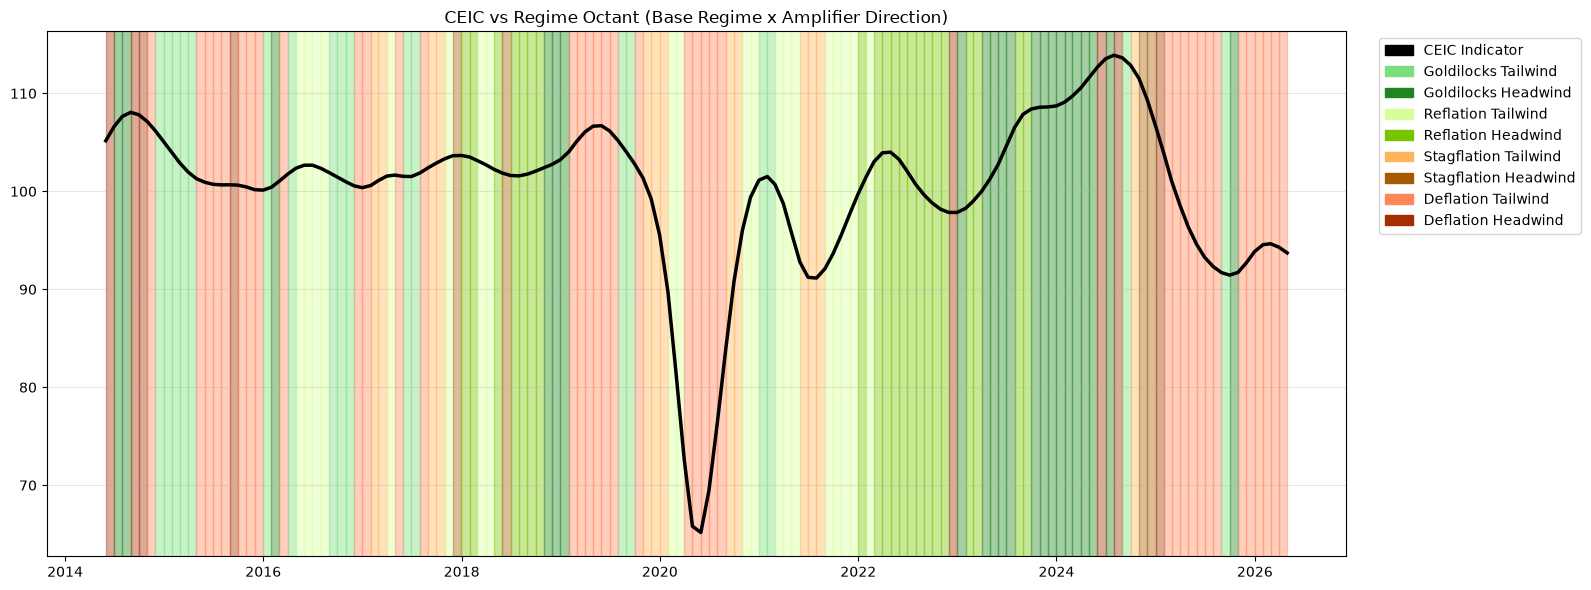

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import colorsys
import seaborn as sns

# =========================================================
# 1. CONFIGURATION
# =========================================================
CEIC_LAG_MONTHS = 0 # Change this value to test your lag hypothesis

# --- COLOR MAPS (Green = Good, Red = Bad/Distress) ---
BASE_COLORS = {
    'Goldilocks': '#32CD32',   # Lime Green
    'Reflation': '#ADFF2F',    # GreenYellow
    'Stagflation': '#FF8C00',  # DarkOrange
    'Deflation': '#FF4500'     # OrangeRed
}

STRENGTH_COLORS = {
    'Significant Tailwind': '#006400', # Dark Green
    'Tailwind': '#32CD32',             # Lime Green
    'Neutral': '#D3D3D3',              # Light Grey
    'Headwind': '#FF8C00',             # Orange
    'Significant Headwind': '#8B0000'  # Dark Red
}

# --- OCTANT COLOR MAP (replaces the old narrative COLOR_MAP for chart 3) ---
# An "octant" is the 8-way split already computed in Step 6C as
# Backtest_Octant: each of the 4 base regime families above crossed with
# the 2 amplifier directions (Tailwind = supportive/easing, Headwind =
# restrictive/tightening). Built from BASE_COLORS by lightening for
# Tailwind and darkening for Headwind, so each octant is still visually
# grouped by family while direction reads as light/dark.
def _adjust_lightness(hex_color, factor):
    """factor > 1 lightens, factor < 1 darkens; hue/saturation unchanged."""
    hex_color = hex_color.lstrip('#')
    r, g, b = (int(hex_color[i:i + 2], 16) / 255.0 for i in (0, 2, 4))
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0.0, min(1.0, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return '#{:02X}{:02X}{:02X}'.format(round(r * 255), round(g * 255), round(b * 255))

OCTANT_COLORS = {}
for _family, _hue in BASE_COLORS.items():
    OCTANT_COLORS[f"{_family} Tailwind"] = _adjust_lightness(_hue, 1.35)
    OCTANT_COLORS[f"{_family} Headwind"] = _adjust_lightness(_hue, 0.65)

# =========================================================
# 2. DATA PREPARATION
# =========================================================
regimes = pd.read_excel('V7_Regime_Output_NoPersistence.xlsx')
regimes['Date'] = pd.to_datetime(regimes['Date'])

ceic = pd.read_csv('India Economy Overview.csv')
date_cols = ceic.columns[27:]
smooth_row = ceic[ceic['Series ID'] == '412736937 (ISAAAALNAAAAYF)']
dates = pd.to_datetime(date_cols, format='%b-%y') + pd.offsets.MonthEnd(0)

ceic_data = pd.DataFrame({'Date': dates, 'CEIC_Smoothed': smooth_row[date_cols].values[0]})
# Apply Lag
ceic_data['CEIC_Smoothed'] = ceic_data['CEIC_Smoothed'].shift(CEIC_LAG_MONTHS)
df = pd.merge(regimes, ceic_data, on='Date', how='inner').sort_values('Date').reset_index(drop=True)

# =========================================================
# 3. STATISTICS
# =========================================================
print(f"--- PEARSON CORRELATION (Lag={CEIC_LAG_MONTHS}m) ---")
print(df[['Composite_Score', 'Amplifier_Score', 'CEIC_Smoothed']].corr().loc['CEIC_Smoothed'])

print("\n--- STATISTICAL AGGREGATION BY OCTANT ---")
_octant_order = [
    f"{family} + {direction}"
    for family in ["Goldilocks", "Reflation", "Stagflation", "Deflation"]
    for direction in ["Tailwind", "Headwind"]
]
octant_stats = df.groupby('Backtest_Octant')[['CEIC_Smoothed']].agg(['median', 'mean', 'count'])
# Order to the 8 canonical octants. Early months that predate the 24-month
# expanding-median warmup (tagged "Unknown (Insufficient Data)" in
# Amplifier_Direction) still shade gray on chart 3 below but are dropped
# from this summary table since they're not a real octant.
octant_stats = octant_stats.reindex([o for o in _octant_order if o in octant_stats.index])
print(octant_stats)

# =========================================================
# 4. PLOTTING SUITE
# =========================================================
def plot_shaded(df, shade_col, color_map, title, filename):
    plt.figure(figsize=(16, 6))
    plt.plot(df['Date'], df['CEIC_Smoothed'], label='CEIC Smoothed', color='black', linewidth=2.5, zorder=5)

    for i in range(1, len(df)):
        val = df[shade_col].iloc[i]
        plt.axvspan(df['Date'].iloc[i-1], df['Date'].iloc[i], color=color_map.get(val, '#D3D3D3'), alpha=0.4, zorder=1)

    patches = [mpatches.Patch(color=color, label=label) for label, color in color_map.items() if label in df[shade_col].unique()]
    plt.legend(handles=[mpatches.Patch(color='black', label='CEIC Indicator')] + patches, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.title(f"{title}")
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# Chart 1 and chart 2 unchanged. Chart 3 now shades by the 8-way regime
# octant (base regime family x amplifier direction) instead of the old
# macro-narrative mapping.
plot_shaded(df, 'Base_Regime_Confirmed', BASE_COLORS, 'CEIC vs Base Regime', 'chart_base.png')
plot_shaded(df, 'Regime_Strength', STRENGTH_COLORS, 'CEIC vs Regime Strength', 'chart_strength.png')
plot_shaded(df, 'Backtest_Octant', OCTANT_COLORS, 'CEIC vs Regime Octant (Base Regime x Amplifier Direction)', 'chart_octant.png')

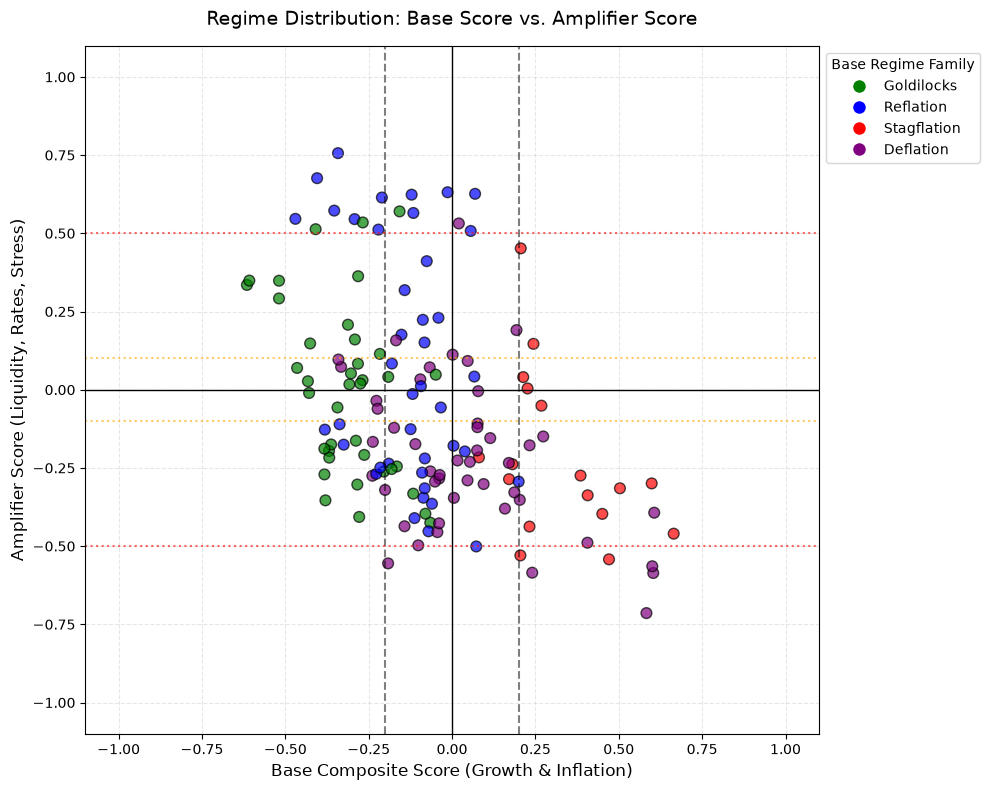

In [13]:
# =========================================================
# SCATTER PLOT: BASE SCORE VS AMPLIFIER SCORE
# =========================================================
plt.figure(figsize=(10, 8))

# Drop NaNs created by the upstream lags to ensure a clean plot
plot_df = df.dropna(subset=["Composite_Score", "Amplifier_Score"]).copy()

# Map base regime families to distinct colors for visual clustering
family_colors = {
    "Goldilocks": "green",
    "Reflation": "blue",
    "Stagflation": "red",
    "Deflation": "purple",
    "Unknown": "gray"
}
colors = plot_df["Base_Regime_Family"].map(family_colors).fillna("gray")

# Create the primary scatter plot
plt.scatter(plot_df["Composite_Score"], plot_df["Amplifier_Score"], 
            c=colors, alpha=0.7, edgecolors='k', s=60)

# Overlay Threshold Lines for Base (Growth/Inflation Momentum Dead Zone)
plt.axvline(x=DEAD_ZONE, color='black', linestyle='--', alpha=0.5, label='Base Dead Zone')
plt.axvline(x=-DEAD_ZONE, color='black', linestyle='--', alpha=0.5)

# Overlay Threshold Lines for Amplifier Strength Bands
plt.axhline(y=HEADWIND_STRENGTH_SIGNIFICANT, color='red', linestyle=':', alpha=0.6, label='Significant Strength')
plt.axhline(y=TAILWIND_STRENGTH_SIGNIFICANT, color='red', linestyle=':', alpha=0.6)
plt.axhline(y=HEADWIND_STRENGTH_MILD, color='orange', linestyle=':', alpha=0.6, label='Mild Strength')
plt.axhline(y=TAILWIND_STRENGTH_MILD, color='orange', linestyle=':', alpha=0.6)

# Standardize plot formatting, labels, and boundaries
plt.title("Regime Distribution: Base Score vs. Amplifier Score", fontsize=14, pad=15)
plt.xlabel("Base Composite Score (Growth & Inflation)", fontsize=12)
plt.ylabel("Amplifier Score (Liquidity, Rates, Stress)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

# Draw origin lines to mark absolute zero for both Base and Amplifier
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Build a custom legend for the regime families
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=label) 
           for label, color in family_colors.items() if label != "Unknown"]
plt.legend(handles=handles, title="Base Regime Family", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

--- BIDIRECTIONAL LAG ANALYSIS (0-MONTH LAG) ---
Option A (Base Leads Amplifier): r = -0.444 | p-value = 0.000
Option B (Amplifier Leads Base): r = -0.444 | p-value = 0.000
---------------------------------------------------------
CEIC vs Amplifier: r = 0.424 | p-value = 0.000


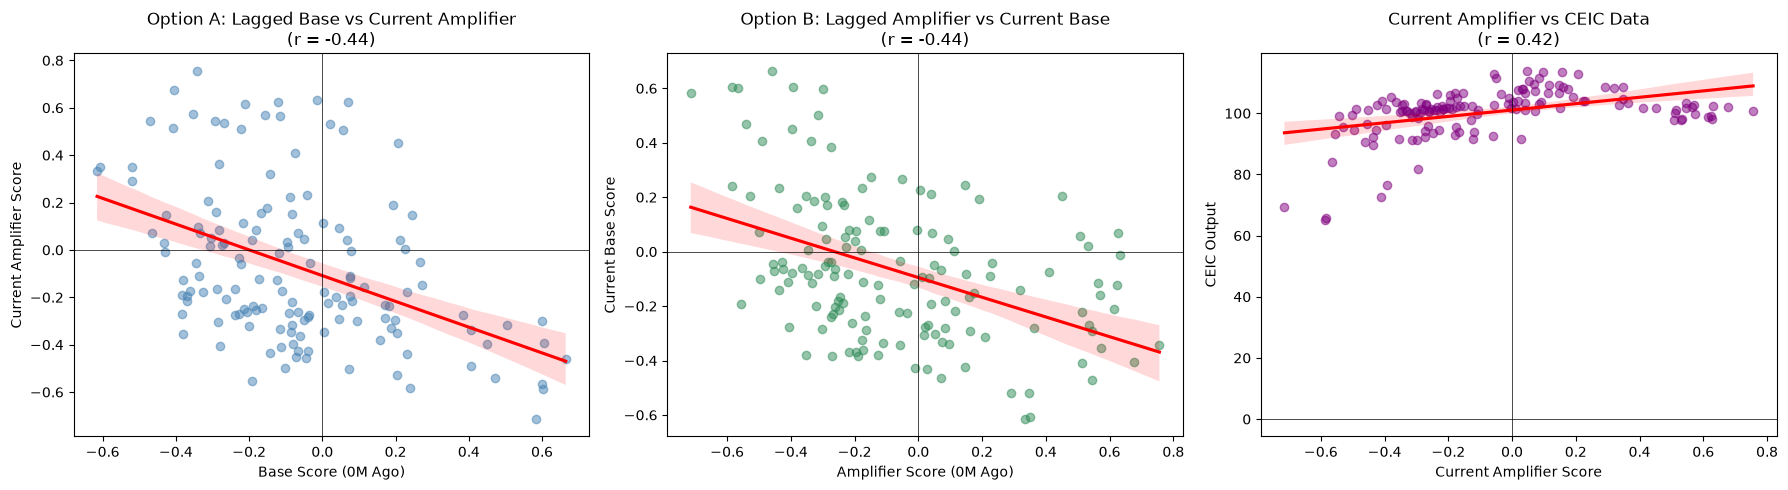

In [14]:
# =========================================================
# ANALYSIS: BIDIRECTIONAL LAGS & CEIC CORRELATION
# =========================================================
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- SETTINGS ---
# Change this value to test different reaction timelines (e.g., 1, 3, 6, 9)
TEST_LAG_MONTHS = 0
AMP_LAG_MONTHS = 0

# Replace this string with the exact column name of your CEIC data in the dataframe
CEIC_COLUMN = "CEIC_Smoothed" 

# 1. Create the lagged columns for both directions
# Option A: Structural environment leads the reaction
base_lag_col = f"Base_Score_Lagged_{TEST_LAG_MONTHS}M"
df[base_lag_col] = df["Composite_Score"].shift(TEST_LAG_MONTHS)

# Option B: Market/Policy reaction leads the structural environment
amp_lag_col = f"Amplifier_Score_Lagged_{AMP_LAG_MONTHS}M"
df[amp_lag_col] = df["Amplifier_Score"].shift(AMP_LAG_MONTHS)

# 2. Drop NaNs to ensure accurate math and plotting for both directions
df_dir_A = df.dropna(subset=[base_lag_col, "Amplifier_Score"]).copy()
df_dir_B = df.dropna(subset=[amp_lag_col, "Composite_Score"]).copy()

# Calculate Pearson correlations
corr_A, p_A = stats.pearsonr(df_dir_A[base_lag_col], df_dir_A["Amplifier_Score"])
corr_B, p_B = stats.pearsonr(df_dir_B[amp_lag_col], df_dir_B["Composite_Score"])

print(f"--- BIDIRECTIONAL LAG ANALYSIS ({TEST_LAG_MONTHS}-MONTH LAG) ---")
print(f"Option A (Base Leads Amplifier): r = {corr_A:.3f} | p-value = {p_A:.3f}")
print(f"Option B (Amplifier Leads Base): r = {corr_B:.3f} | p-value = {p_B:.3f}")
print("---------------------------------------------------------")

# 3. Setup a 1x3 visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Base Leads Amplifier
sns.regplot(
    x=base_lag_col, y="Amplifier_Score", data=df_dir_A,
    scatter_kws={'alpha':0.5, 'color':'steelblue'}, line_kws={'color':'red'}, ax=axes[0]
)
axes[0].set_title(f"Option A: Lagged Base vs Current Amplifier\n(r = {corr_A:.2f})")
axes[0].set_xlabel(f"Base Score ({TEST_LAG_MONTHS}M Ago)")
axes[0].set_ylabel("Current Amplifier Score")
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axvline(0, color='k', linewidth=0.5)

# Plot B: Amplifier Leads Base
sns.regplot(
    x=amp_lag_col, y="Composite_Score", data=df_dir_B,
    scatter_kws={'alpha':0.5, 'color':'seagreen'}, line_kws={'color':'red'}, ax=axes[1]
)
axes[1].set_title(f"Option B: Lagged Amplifier vs Current Base\n(r = {corr_B:.2f})")
axes[1].set_xlabel(f"Amplifier Score ({TEST_LAG_MONTHS}M Ago)")
axes[1].set_ylabel("Current Base Score")
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axvline(0, color='k', linewidth=0.5)

# Plot C: Current Amplifier vs CEIC Output
if CEIC_COLUMN in df.columns:
    df_ceic = df.dropna(subset=["Amplifier_Score", CEIC_COLUMN]).copy()
    corr_C, p_C = stats.pearsonr(df_ceic["Amplifier_Score"], df_ceic[CEIC_COLUMN])
    
    sns.regplot(
        x="Amplifier_Score", y=CEIC_COLUMN, data=df_ceic,
        scatter_kws={'alpha':0.5, 'color':'purple'}, line_kws={'color':'red'}, ax=axes[2]
    )
    axes[2].set_title(f"Current Amplifier vs CEIC Data\n(r = {corr_C:.2f})")
    axes[2].set_xlabel("Current Amplifier Score")
    axes[2].set_ylabel("CEIC Output")
    axes[2].axhline(0, color='k', linewidth=0.5)
    axes[2].axvline(0, color='k', linewidth=0.5)
    print(f"CEIC vs Amplifier: r = {corr_C:.3f} | p-value = {p_C:.3f}")
else:
    # Error handling if the column name isn't updated
    axes[2].text(0.5, 0.5, f"Column '{CEIC_COLUMN}' not found.\nPlease update CEIC_COLUMN variable.", 
                 ha='center', va='center', transform=axes[2].transAxes, color='red')
    axes[2].set_title("CEIC Plot Unavailable")

plt.tight_layout()
plt.show()

In [15]:
# =========================================================
# STEP 8 -- LAG SENSITIVITY SWEEP (per pillar), VALIDATED VS CEIC
#
# Sweeps each pillar's transmission lag (the GROWTH_LAG_MONTHS /
# INFLATION_LAG_MONTHS / LIQUIDITY_LAG_MONTHS / RATES_LAG_MONTHS /
# STRESS_LAG_MONTHS constants set in the CONFIG cell) across a range of
# candidate values, one pillar at a time, holding every other pillar's lag
# at its current CONFIG value. For each candidate it reruns the full
# Step 1-6 pipeline from scratch and reports the same validation checks as
# the bidirectional-lag/CEIC analysis cell: how well Composite_Score
# ("Base") and Amplifier_Score line up with EACH OTHER, and how well each
# lines up with the independent CEIC benchmark. That's the actual accuracy
# read -- internal stability (spell lengths, override rate, etc.) only
# says the series isn't whipsawing, not that it's RIGHT. This does NOT
# change the CONFIG constants -- GROWTH_LAG_MONTHS etc. are read once into
# BASE_LAGS below and the actual df/config in memory is left untouched.
# =========================================================
import scipy.stats as stats

# --- 8.0: confirm shift(n) with n > 0 is a LAG, not a look-ahead ---
_test = pd.Series([10, 20, 30, 40, 50],
                   index=pd.date_range("2020-01-01", periods=5, freq="MS"))
_shifted = _test.shift(3)
assert _shifted.iloc[4] == _test.iloc[1], "shift(n) is not lagging as expected -- investigate before trusting the sweep below"
assert _shifted.iloc[:3].isna().all(), "the first n rows of any lag must be NaN (no earlier data exists yet to fill them)"
print("Lag direction check: PASSED -- shift(n>0) pulls only PAST values forward. No look-ahead.")
print(f"  e.g. value at {_test.index[4].date()} after shift(3) = {_shifted.iloc[4]:.0f}, "
      f"which is the original value from {_test.index[1].date()} (3 months earlier), not a future value.\n")

# --- 8.1: reusable, parameterized rebuild of Steps 1-6 ---
CEIC_COLUMN = "CEIC Smoothed"  # same external benchmark column used in the bidirectional-lag analysis cell

pillar_col_map = {
    "growth": growth_col, "inflation": inflation_col,
    "liquidity": liquidity_col, "rates": rates_col, "stress": stress_col,
}

def load_raw_pillars():
    raw = pd.read_excel("Macro Pillars Attempt 2.xlsx")
    raw.columns = raw.columns.str.strip()
    raw["Date"] = pd.to_datetime(raw["Date"])
    raw = raw.sort_values("Date").reset_index(drop=True)
    raw = raw[raw["Date"] >= DATA_START].reset_index(drop=True)
    for c in pillar_col_map.values():
        raw[c] = raw[c].clip(-1, 1)
    return raw

_RAW_UNLAGGED = load_raw_pillars()
_HAS_CEIC = CEIC_COLUMN in _RAW_UNLAGGED.columns
if not _HAS_CEIC:
    print(f"NOTE: '{CEIC_COLUMN}' not found in the data -- CEIC comparison columns below will be NaN.")

def _safe_corr(x, y):
    paired = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(paired) < 3:
        return np.nan, np.nan, len(paired)
    r, pval = stats.pearsonr(paired["x"], paired["y"])
    return r, pval, len(paired)

def run_pipeline(lags, raw=None):
    raw = _RAW_UNLAGGED if raw is None else raw
    df = raw.copy()
    df[growth_col]    = df[growth_col].shift(lags["growth"])
    df[inflation_col] = df[inflation_col].shift(lags["inflation"])
    df[liquidity_col] = df[liquidity_col].shift(lags["liquidity"])
    df[rates_col]     = df[rates_col].shift(lags["rates"])
    df[stress_col]    = df[stress_col].shift(lags["stress"])

    df["Growth_Final"]    = momentum_adjusted(df[growth_col])
    df["Inflation_Final"] = momentum_adjusted(df[inflation_col])
    df["Composite_Score"] = GROWTH_WEIGHT * df["Growth_Final"] + INFLATION_WEIGHT * df["Inflation_Final"]

    df["Base_Regime_Raw"]    = df.apply(base_regime_raw, axis=1)
    df["Base_Regime_Family"] = df["Base_Regime_Raw"].apply(regime_family)

    # NO-PERSISTENCE VARIANT: raw single-month threshold cross counts directly,
    # no confirm_shock() -- matches the Step 3 change above.
    stress_s, liquidity_s, rates_s = df[stress_col], df[liquidity_col], df[rates_col]
    df["Stress_Shock"] = (stress_s > STRESS_LEVEL_SHOCK_THRESHOLD) | ((stress_s - stress_s.shift(1)) > STRESS_JUMP_SHOCK_THRESHOLD)
    df["Liquidity_Shock"] = (liquidity_s > LIQUIDITY_LEVEL_SHOCK_THRESHOLD) | ((liquidity_s - liquidity_s.shift(1)) > LIQUIDITY_JUMP_SHOCK_THRESHOLD)
    df["Rates_Shock"] = (rates_s > RATES_LEVEL_SHOCK_THRESHOLD) | ((rates_s - rates_s.shift(1)) > RATES_JUMP_SHOCK_THRESHOLD)
    df["Shock_Flag"]  = df["Stress_Shock"] | df["Liquidity_Shock"] | df["Rates_Shock"]
    df["Shock_Onset"] = df["Shock_Flag"] & ~df["Shock_Flag"].shift(1, fill_value=False)

    composite_jump_1m = df["Composite_Score"] - df["Composite_Score"].shift(1)
    df["Regime_Composite_Shock"] = composite_jump_1m.abs() > REGIME_COMPOSITE_JUMP_THRESHOLD
    df["Override_Persistence"]   = df["Shock_Onset"] | df["Regime_Composite_Shock"]

    df["Stress_Smoothed"] = df[stress_col].rolling(2, min_periods=1).mean()
    df["Amplifier_Score"] = df.apply(amplifier_score, axis=1).clip(-1, 1)

    r_base_amp, p_base_amp, n_base_amp = _safe_corr(df["Composite_Score"], df["Amplifier_Score"])

    if _HAS_CEIC:
        r_amp_ceic, p_amp_ceic, n_amp_ceic = _safe_corr(df["Amplifier_Score"], df[CEIC_COLUMN])
        r_base_ceic, p_base_ceic, n_base_ceic = _safe_corr(df["Composite_Score"], df[CEIC_COLUMN])
    else:
        r_amp_ceic = p_amp_ceic = np.nan
        r_base_ceic = p_base_ceic = np.nan
        n_amp_ceic = n_base_ceic = 0

    return {
        "usable_months": {p: int(df[c].notna().sum()) for p, c in pillar_col_map.items()},
        "r_base_amp": r_base_amp, "p_base_amp": p_base_amp, "n_base_amp": n_base_amp,
        "r_amp_ceic": r_amp_ceic, "p_amp_ceic": p_amp_ceic, "n_amp_ceic": n_amp_ceic,
        "r_base_ceic": r_base_ceic, "p_base_ceic": p_base_ceic, "n_base_ceic": n_base_ceic,
    }

# --- 8.2: sweep each pillar's lag independently ---
BASE_LAGS = {
    "growth": GROWTH_LAG_MONTHS, "inflation": INFLATION_LAG_MONTHS,
    "liquidity": LIQUIDITY_LAG_MONTHS, "rates": RATES_LAG_MONTHS,
    "stress": STRESS_LAG_MONTHS,
}
CANDIDATE_LAGS = [0, 2, 4, 6, 8, 10, 12]  # non-negative only -- see Step 8.0

lag_tables = {}
for pillar in BASE_LAGS:
    rows = []
    for lag in CANDIDATE_LAGS:
        trial_lags = dict(BASE_LAGS)
        trial_lags[pillar] = lag
        s = run_pipeline(trial_lags)
        rows.append({
            "Lag (months)": lag,
            "Current config": "<-- yes" if lag == BASE_LAGS[pillar] else "",
            "Usable months": s["usable_months"][pillar],
            "r Base~Amp": round(s["r_base_amp"], 3) if pd.notna(s["r_base_amp"]) else np.nan,
            "p Base~Amp": round(s["p_base_amp"], 3) if pd.notna(s["p_base_amp"]) else np.nan,
            "N Base~Amp": s["n_base_amp"],
            "r Amp~CEIC": round(s["r_amp_ceic"], 3) if pd.notna(s["r_amp_ceic"]) else np.nan,
            "p Amp~CEIC": round(s["p_amp_ceic"], 3) if pd.notna(s["p_amp_ceic"]) else np.nan,
            "N Amp~CEIC": s["n_amp_ceic"],
            "r Base~CEIC": round(s["r_base_ceic"], 3) if pd.notna(s["r_base_ceic"]) else np.nan,
            "p Base~CEIC": round(s["p_base_ceic"], 3) if pd.notna(s["p_base_ceic"]) else np.nan,
            "N Base~CEIC": s["n_base_ceic"],
        })
    lag_tables[pillar] = pd.DataFrame(rows)
    print(f"\n=== {pillar.upper()} -- lag sensitivity vs CEIC and vs each other (other pillars held at CONFIG) ===")
    print(lag_tables[pillar].to_string(index=False))

# Note: r Base~Amp is somewhat circular (that pillar feeds directly into
# Amplifier_Score), so treat r *~CEIC as the more defensible read of which
# lag actually helps.

Lag direction check: PASSED -- shift(n>0) pulls only PAST values forward. No look-ahead.
  e.g. value at 2020-05-01 after shift(3) = 20, which is the original value from 2020-02-01 (3 months earlier), not a future value.

NOTE: 'CEIC Smoothed' not found in the data -- CEIC comparison columns below will be NaN.

=== GROWTH -- lag sensitivity vs CEIC and vs each other (other pillars held at CONFIG) ===
 Lag (months) Current config  Usable months  r Base~Amp  p Base~Amp  N Base~Amp  r Amp~CEIC  p Amp~CEIC  N Amp~CEIC  r Base~CEIC  p Base~CEIC  N Base~CEIC
            0        <-- yes            145      -0.441       0.000         145         NaN         NaN           0          NaN          NaN            0
            2                           143      -0.390       0.000         143         NaN         NaN           0          NaN          NaN            0
            4                           141      -0.346       0.000         141         NaN         NaN           0          NaN   

<>:120: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:120: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/var/folders/q5/pq31bcf10fv9ktv6b14g42zr0000gn/T/ipykernel_26035/175161197.py:120: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  label="Dynamic OOS $\epsilon$-Belt"


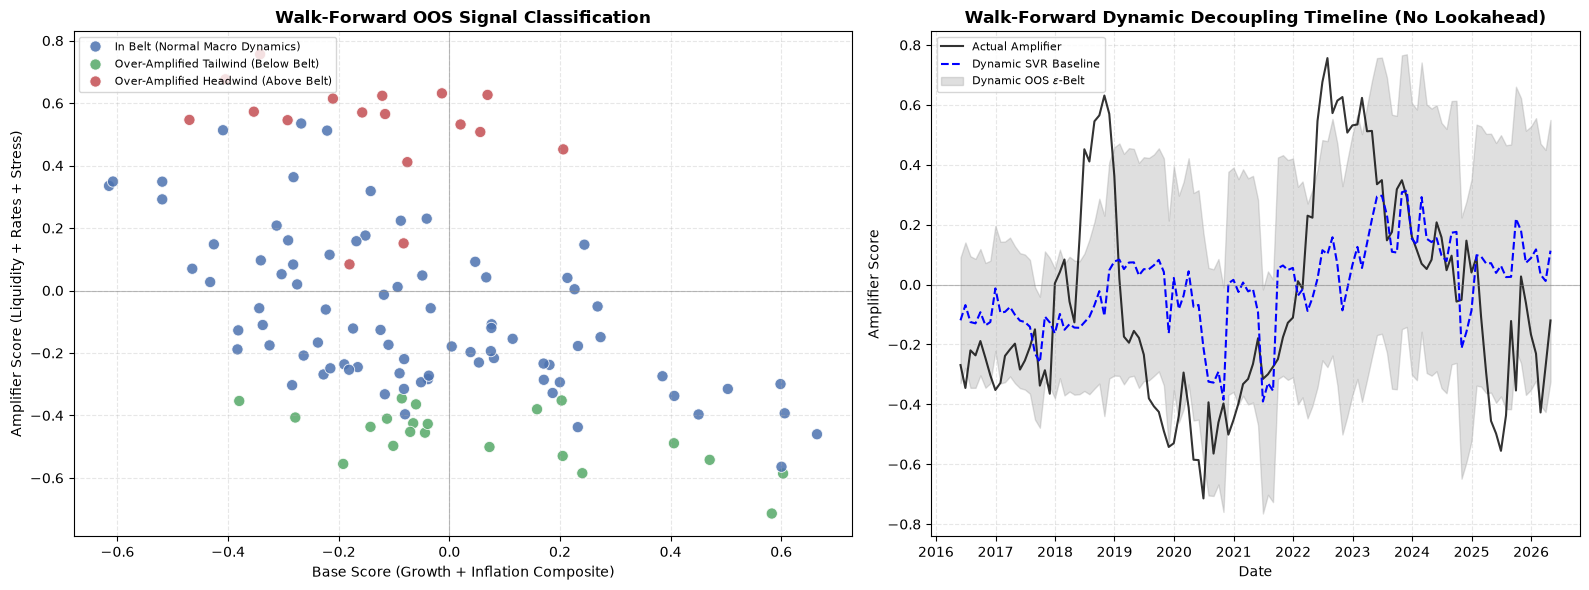

--- WALK-FORWARD (OUT-OF-SAMPLE) DIAGNOSTIC SUMMARY ---
Evaluated OOS Months: 120
  * In Belt (Normal Macro Dynamics)       :  82 months (68.3%)
  * Over-Amplified Tailwind (Below Belt)  :  21 months (17.5%)
  * Over-Amplified Headwind (Above Belt)  :  17 months (14.2%)
Tailwind Months (21): [Timestamp('2016-06-30 00:00:00'), Timestamp('2016-12-31 00:00:00'), Timestamp('2017-11-30 00:00:00'), Timestamp('2019-07-31 00:00:00'), Timestamp('2019-08-31 00:00:00'), Timestamp('2019-09-30 00:00:00'), Timestamp('2019-10-31 00:00:00'), Timestamp('2019-11-30 00:00:00'), Timestamp('2019-12-31 00:00:00'), Timestamp('2020-03-31 00:00:00'), Timestamp('2020-04-30 00:00:00'), Timestamp('2020-05-31 00:00:00'), Timestamp('2020-06-30 00:00:00'), Timestamp('2020-11-30 00:00:00'), Timestamp('2020-12-31 00:00:00'), Timestamp('2025-04-30 00:00:00'), Timestamp('2025-05-31 00:00:00'), Timestamp('2025-06-30 00:00:00'), Timestamp('2025-07-31 00:00:00'), Timestamp('2025-09-30 00:00:00'), Timestamp('2026-02-28 00:0

In [16]:
# =========================================================
# FULL WALK-FORWARD (OUT-OF-SAMPLE) EPSILON-TUBE MODEL
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVR

# 1. Clean & Sort Data Chronologically
clean_df = df.dropna(subset=["Composite_Score", "Amplifier_Score"]).sort_values("Date").reset_index(drop=True)

# 2. Define Expanding Window Parameters
MIN_TRAIN_SIZE = 24     # Requires 3 years of initial data before producing OOS signals
SIGMA_MULTIPLIER = 1.5  # Dynamic epsilon = 1.5 * historical residual standard deviation
C_VAL = 5.0             # Regularization parameter

# Storage arrays for walk-forward loop
oos_signals = [np.nan] * len(clean_df)
oos_expected = [np.nan] * len(clean_df)
oos_upper = [np.nan] * len(clean_df)
oos_lower = [np.nan] * len(clean_df)

# 3. Walk-Forward Loop (Strictly Out-of-Sample)
for i in range(MIN_TRAIN_SIZE, len(clean_df)):
    # Slice historical training window (Months 0 to i-1)
    train_hist = clean_df.iloc[:i]
    X_train = train_hist[["Composite_Score"]].values
    y_train = train_hist["Amplifier_Score"].values
    
    # Current month to evaluate (Month i)
    current_row = clean_df.iloc[i]
    X_curr = np.array([[current_row["Composite_Score"]]])
    y_curr = current_row["Amplifier_Score"]
    
    # Step A: Fit initial SVR to calculate historical noise level (residual std dev)
    init_svr = SVR(kernel='rbf', C=C_VAL, epsilon=0.1)
    init_svr.fit(X_train, y_train)
    hist_residuals = y_train - init_svr.predict(X_train)
    
    # Step B: Dynamically derive epsilon for month i using ONLY historical volatility
    dynamic_epsilon = SIGMA_MULTIPLIER * np.std(hist_residuals)
    
    # Step C: Re-fit final SVR model with historical dynamic epsilon
    svr_t = SVR(kernel='rbf', C=C_VAL, epsilon=dynamic_epsilon)
    svr_t.fit(X_train, y_train)
    
    # Step D: Predict current out-of-sample value
    pred_y = svr_t.predict(X_curr)[0]
    upper_bound = pred_y + dynamic_epsilon
    lower_bound = pred_y - dynamic_epsilon
    
    # Step E: Classify out-of-sample status
    if y_curr > upper_bound:
        status = "Over-Amplified Headwind (Above Belt)"
    elif y_curr < lower_bound:
        status = "Over-Amplified Tailwind (Below Belt)"
    else:
        status = "In Belt (Normal Macro Dynamics)"
        
    # Record results
    oos_signals[i] = status
    oos_expected[i] = pred_y
    oos_upper[i] = upper_bound
    oos_lower[i] = lower_bound

# 4. Attach Out-of-Sample Outputs to DataFrame
clean_df["OOS_Signal"] = oos_signals
clean_df["OOS_Expected_Amplifier"] = oos_expected
clean_df["OOS_Tube_Upper"] = oos_upper
clean_df["OOS_Tube_Lower"] = oos_lower

# Merge back into original main DataFrame if needed
df = df.merge(
    clean_df[["Date", "OOS_Signal", "OOS_Expected_Amplifier", "OOS_Tube_Upper", "OOS_Tube_Lower"]], 
    on="Date", 
    how="left"
)

# 5. Visualizations (Out-of-Sample Results)
eval_df = clean_df.dropna(subset=["OOS_Signal"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.2, 1]})

palette = {
    "In Belt (Normal Macro Dynamics)": "#4C72B0",
    "Over-Amplified Headwind (Above Belt)": "#C44E52",
    "Over-Amplified Tailwind (Below Belt)": "#55A868"
}

# --- Plot A: Scatter of OOS Classified Signals ---
sns.scatterplot(
    data=eval_df, 
    x="Composite_Score", 
    y="Amplifier_Score", 
    hue="OOS_Signal", 
    palette=palette,
    s=65, 
    alpha=0.85, 
    ax=axes[0]
)

axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="-", alpha=0.5)
axes[0].axvline(0, color="gray", linewidth=0.8, linestyle="-", alpha=0.5)
axes[0].set_title("Walk-Forward OOS Signal Classification", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Base Score (Growth + Inflation Composite)", fontsize=10)
axes[0].set_ylabel("Amplifier Score (Liquidity + Rates + Stress)", fontsize=10)
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(True, linestyle="--", alpha=0.3)

# --- Plot B: Walk-Forward Dynamic Tube Timeline ---
axes[1].plot(eval_df["Date"], eval_df["Amplifier_Score"], color="black", linewidth=1.5, label="Actual Amplifier", alpha=0.8)
axes[1].plot(eval_df["Date"], eval_df["OOS_Expected_Amplifier"], color="blue", linewidth=1.5, linestyle="--", label="Dynamic SVR Baseline")
axes[1].fill_between(
    eval_df["Date"], 
    eval_df["OOS_Tube_Lower"], 
    eval_df["OOS_Tube_Upper"], 
    color="gray", 
    alpha=0.25, 
    label="Dynamic OOS $\epsilon$-Belt"
)

axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="-", alpha=0.5)
axes[1].set_title("Walk-Forward Dynamic Decoupling Timeline (No Lookahead)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Date", fontsize=10)
axes[1].set_ylabel("Amplifier Score", fontsize=10)
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Out-of-Sample Diagnostic Report
print("--- WALK-FORWARD (OUT-OF-SAMPLE) DIAGNOSTIC SUMMARY ---")
print(f"Evaluated OOS Months: {len(eval_df)}")
status_counts = eval_df["OOS_Signal"].value_counts()
for status, count in status_counts.items():
    pct = (count / len(eval_df)) * 100
    print(f"  * {status:38s}: {count:3d} months ({pct:.1f}%)")

# Quick filter for Tailwind and Headwind dates
tailwinds = eval_df[eval_df["OOS_Signal"].str.contains("Tailwind")]["Date"].tolist()
headwinds = eval_df[eval_df["OOS_Signal"].str.contains("Headwind")]["Date"].tolist()

print(f"Tailwind Months ({len(tailwinds)}):", tailwinds)
print(f"Headwind Months ({len(headwinds)}):", headwinds)


